## 神经网络入门
我们将从张量计算框架（PyTorch）入手，介绍一个简单的神经网络——多层感知机MultiLayer Perceptron应该长什么样，再倒回去通过介绍实现神经网络的技术——自动微分、反向传播，动手构建一个MLP。

### 前言：选择什么样的深度学习库
我会推荐大家使用PyTorch。PyTorch 是当前学学术界和工业界的主流。根据近年的论文统计、Kaggle 竞赛使用率以及 GitHub 活跃度，PyTorch 已成为深度学习的事实标准。TensorFlow 虽然在部署端仍有优势，但其早期静态计算图的设计对初学者不友好；MXNet 则基本退出了主流生态。而 PyTorch 的动态计算图（eager execution）让你像写普通 Python 一样调试模型——这对理解自动微分和构建直觉至关重要。更重要的是，几乎所有最新的金融 AI 研究（比如用深度学习解 HJB方程、学习 SDE 的生成模型）。
- 安装方法：[Torch官网](https://pytorch.org/)

不同的GPU适配的是不同的CUDA，不同的CUDA能使用的Torch版本不一样。像我的GPU比较老只适配到CUDA12.1，所以我的环境是Py3.9+Torch2.5.1+CUDA12.1。
- 在prompt界面nvidia-smi查看自己的GPU最高支持的CUDA版本（[Nvidia](https://developer.nvidia.com/cuda-toolkit-archive)）然后nvcc --version检查自己是否安装上了。
> 没有Nvida显卡的同学~~遗憾离场~~（不是）
>
>Torch允许只用CPU允许，就是速度*比较*慢而已。如果真有需要的训练的可以租用云服务器。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
x = torch.arange(12)
x

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

### 一、为什么我们要搞神经网络
> 搞计量的那帮家伙教我们要用线性的模型来做实证。但是，线性模型真的是现实中数据生成的过程吗？

#### 1. 从线性回归说起：一个神经元
数据的生成过程总是不得而知。如果总是用线性模型的话，那模型多半是有偏的、不一致的（形式误设）。即便我们加入高次项，可问题是高次项和高次项也不一样。谁敢说面对U型问题，把 $x$ 改成 $x^2$ 就是完美的了？万一真实过程是 $x^4$ 呢？

回想一下线性回归:
$$
\hat{y} = w_1x_1 + w_2x_2 + \cdots + w_dx_d + b \\
\hat{y} = w^T x + b
$$

在神经网络里，我们可以把这个结构称为一个 **“神经元”**（neuron）：
- 输入：$\mathbf{x} \in \mathbb{R}^d$
- 权重：$\mathbf{w} \in \mathbb{R}^d$
- 偏置：$b \in \mathbb{R}$
- 输出：先做线性变换 $z = \mathbf{w}^\top \mathbf{x} + b$，再通过一个 **激活函数**（activation function）$\sigma(\cdot)$ 得到最终输出：
  $$
  a = \sigma(z) = \sigma(\mathbf{w}^\top \mathbf{x} + b)
  $$

> **激活函数引入了非线性**。如果没有它，无论堆多少层，整个网络还是线性的。

常见激活函数：
- ReLU：$\sigma(z) = \max(0, z)$ —— 简单、高效、金融中常用（类似“阈值效应”）；
- tanh：$\sigma(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ —— 输出在 $(-1,1)$，平滑；
- Sigmoid：$\sigma(z) = \frac{1}{1 + e^{-z}}$ —— 输出在 $(0,1)$，适合概率建模。

---
有大牛帮我们[证明](https://www.sciencedirect.com/science/article/abs/pii/089360809190009T)了一个够深够大、配上非线性激活函数的神经网络可以在**训练集**内拟合任何函数。

~~但是学校没有买这个文章~~……不过不是做统计的同学也没必要深究，讲这个就是让大家确信函数是可以被很好拟合的。

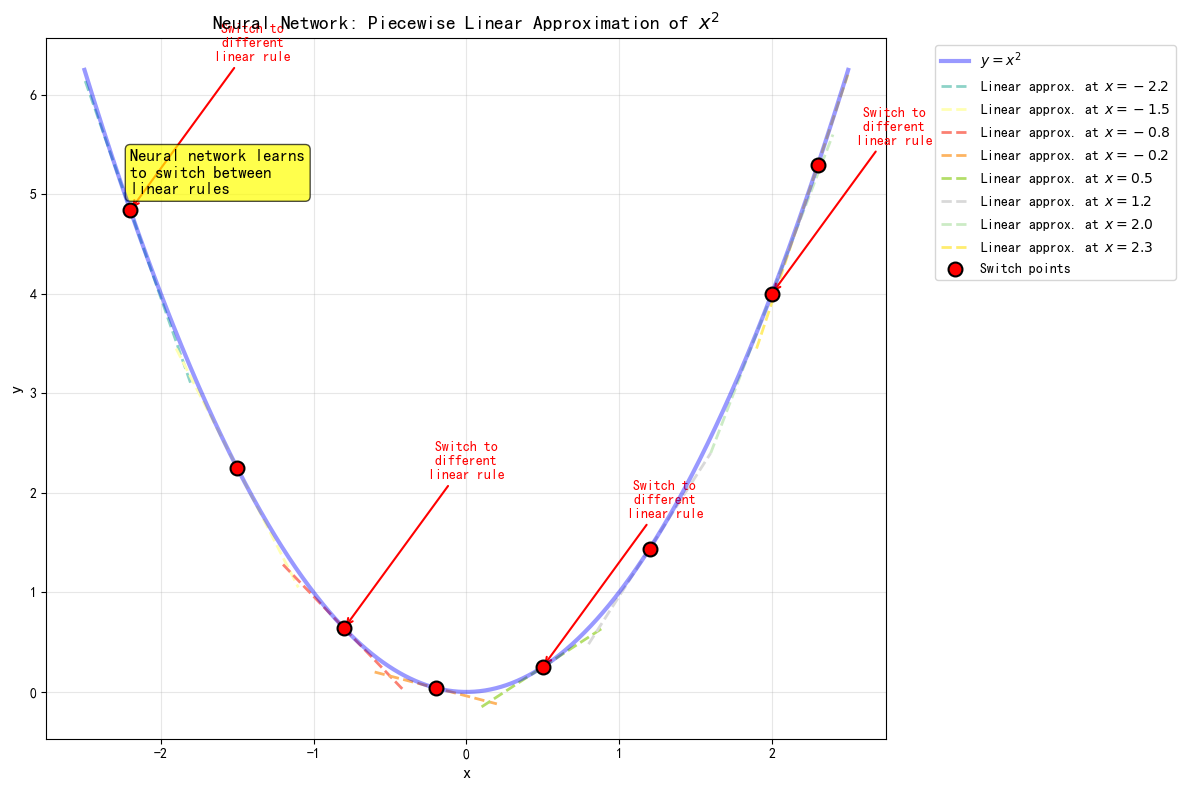

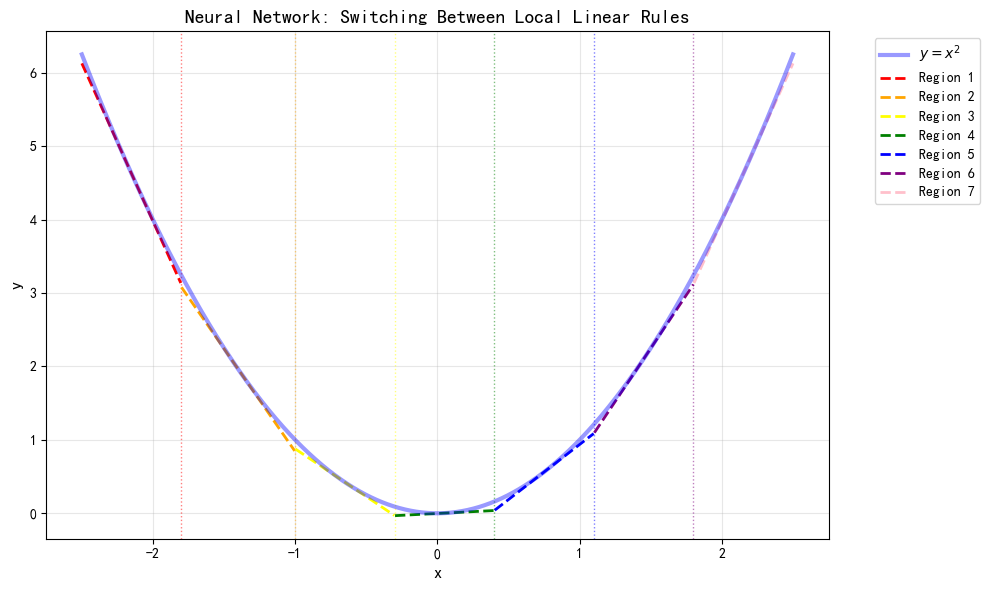

In [4]:
# 设置随机种子以复现结果
np.random.seed(42)

# 定义x^2函数
x_true = np.linspace(-2.5, 2.5, 1000)
y_true = x_true ** 2

# 定义分段线性函数的分割点
segment_points = np.array([-2.2, -1.5, -0.8, -0.2, 0.5, 1.2, 2.0, 2.3])

# 为每个段创建线性函数
# 我们使用x^2在各点处的切线作为近似
def get_tangent_line(x0, func):
    """获取函数在x0处的切线"""
    y0 = func(x0)
    slope = 2 * x0  # x^2的导数是2x
    return lambda x: slope * (x - x0) + y0

# 创建分段线性函数
segment_functions = []
for x0 in segment_points:
    tangent_func = get_tangent_line(x0, lambda x: x**2)
    segment_functions.append(tangent_func)

# 创建图形（保留第一张图）
plt.figure(figsize=(12, 8))

# 绘制真实的x^2函数（降低透明度）
plt.plot(x_true, y_true, 'b-', linewidth=3, label='$y = x^2$', zorder=5, alpha=0.4)

# 绘制分段线性近似（使其不透明）
colors = plt.cm.Set3(np.linspace(0, 1, len(segment_functions)))  # 使用不同颜色

for i, (x0, func, color) in enumerate(zip(segment_points, segment_functions, colors)):
    # 定义线性段的范围（围绕切点）
    x_seg = np.linspace(x0 - 0.4, x0 + 0.4, 100)
    y_seg = func(x_seg)
    
    # 只显示在合理范围内的部分
    mask = (x_seg >= -2.5) & (x_seg <= 2.5)
    x_seg = x_seg[mask]
    y_seg = y_seg[mask]
    
    plt.plot(x_seg, y_seg, '--', color=color, linewidth=2, 
             label=f'Linear approx. at $x={x0:.1f}$', alpha=1.0, zorder=3)

# 标记分割点（激活函数切换的点）
plt.scatter(segment_points, segment_points**2, color='red', s=100, 
           zorder=6, edgecolor='black', linewidth=1.5, label='Switch points')

# 添加箭头指向分割点
for x0 in segment_points[::2]:  # 每隔一个点添加箭头，避免重叠
    plt.annotate(f'Switch to\ndifferent\nlinear rule', 
                xy=(x0, x0**2), xytext=(x0+0.8, x0**2+1.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=10, ha='center', color='red', weight='bold')

# 添加说明文本
plt.text(-2.2, 5, 'Neural network learns\nto switch between\nlinear rules', 
         fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Neural Network: Piecewise Linear Approximation of $x^2$', fontsize=14, weight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 第三个图：展示神经网络如何"感知"到切换点（保留为最后一张图）
plt.figure(figsize=(10, 6))

x_range = np.linspace(-2.5, 2.5, 1000)
y_range = x_range ** 2

# 绘制真实的x^2函数（降低透明度）
plt.plot(x_range, y_range, 'b-', linewidth=3, label='$y = x^2$', zorder=5, alpha=0.4)

# 用不同颜色的线段表示不同的"区域"（切线近似改为不透明）
regions = [(-2.5, -1.8), (-1.8, -1.0), (-1.0, -0.3), (-0.3, 0.4), (0.4, 1.1), (1.1, 1.8), (1.8, 2.5)]
region_colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']

for i, ((x_start, x_end), color) in enumerate(zip(regions, region_colors)):
    x_seg = x_range[(x_range >= x_start) & (x_range <= x_end)]
    y_seg = x_seg ** 2
    
    # 用切线近似
    x_mid = (x_start + x_end) / 2
    slope = 2 * x_mid
    y_mid = x_mid ** 2
    tangent_line = slope * (x_seg - x_mid) + y_mid
    
    plt.plot(x_seg, tangent_line, '--', color=color, linewidth=2, 
             label=f'Region {i+1}', alpha=1.0)
    
    # 标记区域边界
    if i < len(regions) - 1:  # 不标记最后一个边界
        boundary_x = x_end
        plt.axvline(x=boundary_x, color=color, linestyle=':', alpha=0.5, linewidth=1)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Neural Network: Switching Between Local Linear Rules', fontsize=14, weight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. 单层感知机：多个神经元并行

现在，我们不只用一个神经元，而是用 **$m$ 个神经元并行处理同一输入**。这就构成了**一层隐藏层**（hidden layer）。

对每个神经元 $j = 1, \dots, m$：
$$
z_j = \mathbf{w}_j^\top \mathbf{x} + b_j,\quad a_j = \sigma(z_j)
$$

把所有权重拼成矩阵 $\mathbf{W} \in \mathbb{R}^{m \times d}$，偏置拼成向量 $\mathbf{b} \in \mathbb{R}^m$，则整个层的输出为：
$$
\mathbf{a} = \sigma(\mathbf{W} \mathbf{x} + \mathbf{b})
$$
其中 $\sigma$ 是**逐元素**（element-wise）应用的。

> 这就是**单隐藏层感知机**：输入 → 线性变换 → 非线性激活 → 输出。

但注意：它的输出 $\mathbf{a}$ 是一个**向量**，维度是隐藏层宽度 $m$。

---

Epoch 0, Loss: 4.697596
Epoch 200, Loss: 0.129598
Epoch 400, Loss: 0.057673
Epoch 600, Loss: 0.029356
Epoch 800, Loss: 0.018561


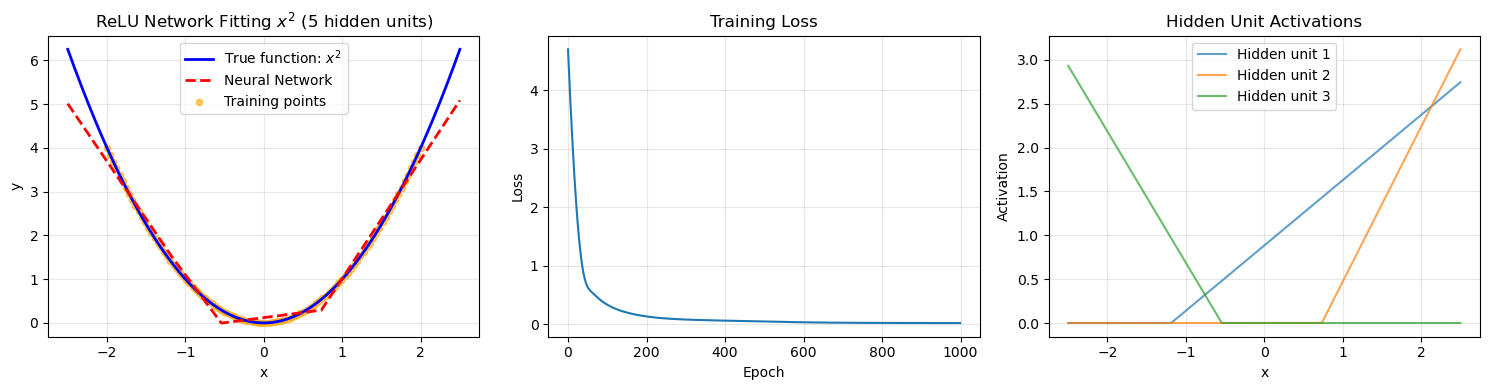


Network parameters:
Hidden layer weights: [ 0.74373055  1.7644567  -1.4962087 ]
Hidden layer biases: [ 0.8842643 -1.2923584 -0.8101831]
Output layer weights: [0.31118327 1.4062474  1.7616407 ]
Output layer bias: -0.15505638718605042

Explanation:
Each ReLU hidden unit creates a 'kink' in the final function.
The network learns to use different linear pieces in different regions
to approximate the parabolic shape of x^2.


In [6]:
# 设置随机种子以复现结果
torch.manual_seed(42)
np.random.seed(42)

# 给定不同隐藏节点数，会是什么样呢？
inner_nodes = 3

# 定义神经网络
class SimpleNet(nn.Module):
    def __init__(self, n_nodes = inner_nodes):
        super(SimpleNet, self).__init__()
        self.hidden = nn.Linear(1, n_nodes)  # 5个隐藏节点
        self.output = nn.Linear(n_nodes, 1)
    
    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = self.output(x)
        return x

# 生成训练数据
x_train = torch.linspace(-2, 2, 100).reshape(-1, 1)
y_train = x_train ** 2

# 初始化网络和优化器
net = SimpleNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

# 训练网络
losses = []
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = net(x_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if epoch % 200 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')

# 绘制结果
plt.figure(figsize=(15, 4))

# 子图1：训练数据和拟合结果
plt.subplot(1, 3, 1)
x_plot = np.linspace(-2.5, 2.5, 400)
y_true = x_plot ** 2
x_tensor = torch.tensor(x_plot.reshape(-1, 1), dtype=torch.float32)
y_pred = net(x_tensor).detach().numpy()

plt.plot(x_plot, y_true, 'b-', label='True function: $x^2$', linewidth=2)
plt.plot(x_plot, y_pred, 'r--', label='Neural Network', linewidth=2)
plt.scatter(x_train.numpy().flatten(), y_train.numpy().flatten(), 
           c='orange', alpha=0.6, s=20, label='Training points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('ReLU Network Fitting $x^2$ (5 hidden units)')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2：损失曲线
plt.subplot(1, 3, 2)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)

# 子图3：可视化每个隐藏单元的激活
plt.subplot(1, 3, 3)
x_tensor = torch.tensor(x_plot.reshape(-1, 1), dtype=torch.float32)
hidden_outputs = torch.relu(net.hidden(x_tensor)).detach().numpy()

for i in range(inner_nodes):
    plt.plot(x_plot, hidden_outputs[:, i], label=f'Hidden unit {i+1}', alpha=0.7)

plt.xlabel('x')
plt.ylabel('Activation')
plt.title('Hidden Unit Activations')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印网络参数和解释
print("\nNetwork parameters:")
print(f"Hidden layer weights: {net.hidden.weight.data.numpy().flatten()}")
print(f"Hidden layer biases: {net.hidden.bias.data.numpy()}")
print(f"Output layer weights: {net.output.weight.data.numpy().flatten()}")
print(f"Output layer bias: {net.output.bias.data.item()}")

print("\nExplanation:")
print("Each ReLU hidden unit creates a 'kink' in the final function.")
print("The network learns to use different linear pieces in different regions")
print("to approximate the parabolic shape of x^2.")

##### 直接拟合带周期函数的后果
MLP没有“周期”的概念，它只学会在训练数据覆盖的范围内拟合局部形状，却不知道函数应重复。

- 训练数据覆盖范围 = 模型能力边界  
- 外推失效的本质：  无法感知数据生成机制的结构性变化  
- **过往业绩不代表现在**在一切只有相关、不知道因果的地方都生效，相关性无法和因果性画上等号。

Epoch 0, Loss: 7.132045
Epoch 1000, Loss: 0.313819
Epoch 1000, Loss: 0.313819
Epoch 2000, Loss: 0.279594
Epoch 2000, Loss: 0.279594
Epoch 3000, Loss: 0.290738
Epoch 3000, Loss: 0.290738
Epoch 4000, Loss: 0.279516
Epoch 4000, Loss: 0.279516


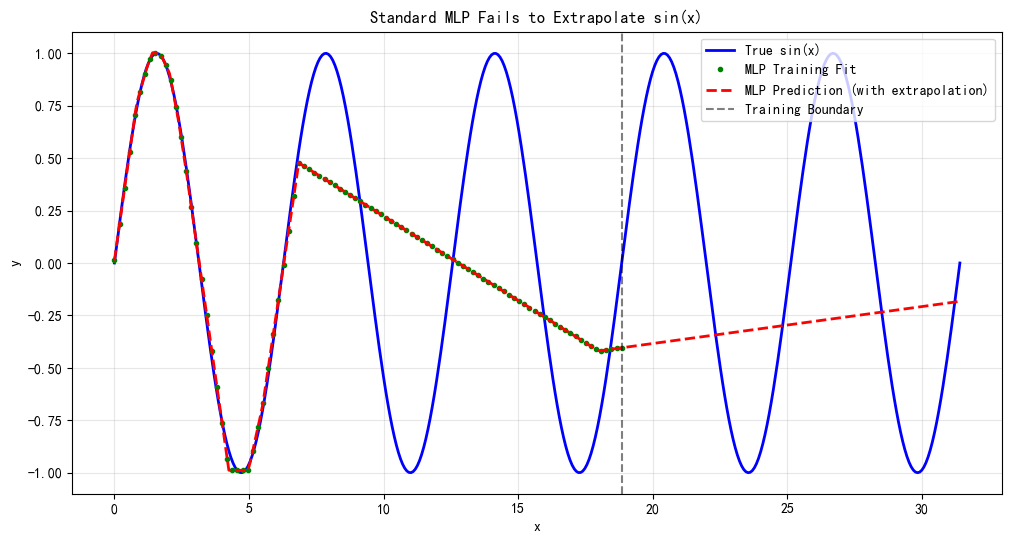

In [5]:
torch.manual_seed(42)
np.random.seed(42)

# 生成数据
x_train = np.linspace(0, 6*np.pi, 100).reshape(-1, 1)
y_train = np.sin(x_train)

x_test = np.linspace(0, 10*np.pi, 400).reshape(-1, 1)  # 包含外推区域
y_test = np.sin(x_test)

# 构建MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

# 训练
model = MLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(5000):
    optimizer.zero_grad()
    y_pred = model(torch.tensor(x_train, dtype=torch.float32))
    loss = criterion(y_pred, torch.tensor(y_train, dtype=torch.float32))
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')

# 预测
with torch.no_grad():
    y_pred_train = model(torch.tensor(x_train, dtype=torch.float32)).numpy()
    y_pred_test = model(torch.tensor(x_test, dtype=torch.float32)).numpy()

# 可视化
plt.figure(figsize=(12, 6))
plt.plot(x_test, y_test, 'b-', linewidth=2, label='True sin(x)')
plt.plot(x_train, y_pred_train, 'go', markersize=3, label='MLP Training Fit')
plt.plot(x_test, y_pred_test, 'r--', linewidth=2, label='MLP Prediction (with extrapolation)')
plt.axvline(x=6*np.pi, color='k', linestyle='--', alpha=0.5, label='Training Boundary')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard MLP Fails to Extrapolate sin(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

SIREN Epoch 0, Loss: 0.504941
SIREN Epoch 2000, Loss: 0.001644
SIREN Epoch 2000, Loss: 0.001644
SIREN Epoch 4000, Loss: 0.001135
SIREN Epoch 4000, Loss: 0.001135
SIREN Epoch 6000, Loss: 0.000959
SIREN Epoch 6000, Loss: 0.000959
SIREN Epoch 8000, Loss: 0.000927
SIREN Epoch 8000, Loss: 0.000927


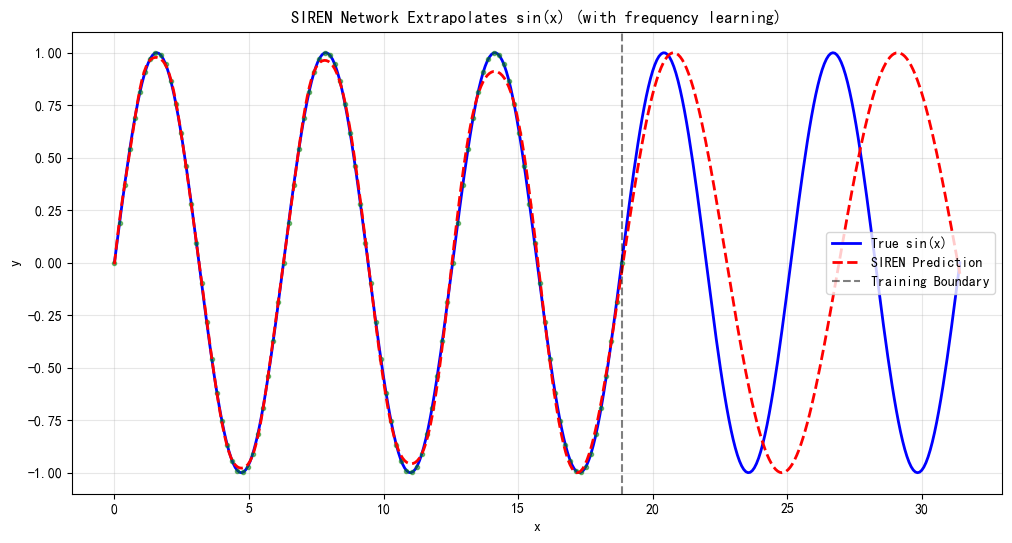

In [6]:
# SIREN: 网络使用正弦激活函数
class SIREN(nn.Module):
    def __init__(self, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),  # 或直接用sin，但SiLU更稳定
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )
        # 特殊初始化：首层权重缩放
        with torch.no_grad():
            self.net[0].weight.uniform_(-1/self.omega_0, 1/self.omega_0)
    
    def forward(self, x):
        return torch.sin(self.omega_0 * self.net(x))

# 使用SIREN拟合
siren = SIREN(omega_0=1.0)  # 初始频率猜测
optimizer = optim.Adam(siren.parameters(), lr=1e-3)

for epoch in range(10000):
    optimizer.zero_grad()
    y_pred = siren(torch.tensor(x_train, dtype=torch.float32))
    loss = criterion(y_pred, torch.tensor(y_train, dtype=torch.float32))
    loss.backward()
    optimizer.step()
    if epoch % 2000 == 0:
        print(f'SIREN Epoch {epoch}, Loss: {loss.item():.6f}')

# 预测
with torch.no_grad():
    y_pred_siren = siren(torch.tensor(x_test, dtype=torch.float32)).numpy()

# 可视化
plt.figure(figsize=(12, 6))
plt.plot(x_test, y_test, 'b-', linewidth=2, label='True sin(x)')
plt.plot(x_train, y_train, 'go', markersize=3, alpha=0.5)
plt.plot(x_test, y_pred_siren, 'r--', linewidth=2, label='SIREN Prediction')
plt.axvline(x=6*np.pi, color='k', linestyle='--', alpha=0.5, label='Training Boundary')
plt.xlabel('x')
plt.ylabel('y')
plt.title('SIREN Network Extrapolates sin(x) (with frequency learning)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### 选用激活函数的注意事项：
唯一禁止的操作就是：用**线性函数**来当一个线性神经元的激活函数！
不然，假如一个隐藏层的神经元是 $$H = XW_1 + b_1$$
另外有激活函数 $$O=HW_2 +b_2$$
那么既然如此，我们何不联立起来
$$O = (XW_1 + b_1)W_2 + b_2 = X(W_1 \cdot W_2) +(b_1 W_2 + b_2)$$
还是相当于一个线性函数，使用激活函数成了多此一举。而且没有任何增益，任何由O提供的增益都已经在H中实现。

#### 3. 多层感知机：堆叠隐藏层
##### 一、首先，为什么选择叠深度而不是只叠广度：
一个单隐藏层网络，使用非线性激活函数（如 sigmoid、ReLU），只要隐藏单元数量足够多，就能在紧集上一致逼近任何连续函数。但是这有几个条件：隐藏单元数会指数级增长、逼近只在compact set（人话：我们训练用的一小块区域）上成立。

深度网络通过层次化组合，能高效表示复合函数。也已经有一堆[大](https://arxiv.org/abs/1602.04485)[牛](https://arxiv.org/abs/1512.03965)帮我们证明了这一点。

##### 二、多层感知机的套路
现在，我们把上一层的输出 $\mathbf{a}^{(1)}$ 作为下一层的输入，继续做线性变换 + 激活：

- 第1层（输入 → 隐藏1）：
  $$
  \mathbf{z}^{(1)} = \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)},\quad \mathbf{a}^{(1)} = \sigma(\mathbf{z}^{(1)})
  $$

- 第2层（隐藏1 → 隐藏2）：
  $$
  \mathbf{z}^{(2)} = \mathbf{W}^{(2)} \mathbf{a}^{(1)} + \mathbf{b}^{(2)},\quad \mathbf{a}^{(2)} = \sigma(\mathbf{z}^{(2)})
  $$

- ……

- 最后一层（输出层）：
  $$
  \hat{y} = \mathbf{w}^{(L)\top} \mathbf{a}^{(L-1)} + b^{(L)}
  $$
  （输出层作为结果，不怎么需要加激活函数）

>  **整个 MLP 就是一系列仿射变换**（affine transformation）

这个结构可以写成一个复合函数：
$$
\hat{y} = f_{\boldsymbol{\theta}}(\mathbf{x}) = \mathbf{w}^{(L)\top} \sigma\big( \cdots \sigma(\mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)}) \cdots \big) + b^{(L)}
$$
其中 $\boldsymbol{\theta}$ 表示所有参数：$\{\mathbf{W}^{(1)}, \mathbf{b}^{(1)}, \dots, \mathbf{w}^{(L)}, b^{(L)}\}$。

---

#### **4. 如何学习参数**？
##### 一、 更新参数的依据
我们要找一组参数 $\boldsymbol{\theta}$，使得预测 $\hat{y}_i$ 尽可能接近真实值 $y_i$。

定义损失函数（比如均方误差MSE）：
$$
\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^n (y_i - f_{\boldsymbol{\theta}}(\mathbf{x}_i))^2
$$

为了最小化 $\mathcal{L}$，我们需要：
1. 计算损失对每个参数的**偏导数**（梯度）；
2. 沿梯度反方向更新参数（梯度下降）。

> 梯度的值告诉了我们：损失函数在某方向上有多么敏感。

**问题来了：这个复合函数的导数怎么算**？

以一个两层网络为例：
$$
\hat{y} = \mathbf{w}^{(2)\top} \sigma(\mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)}) + b^{(2)}
$$

你想求 $\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(1)}}$。根据链式法则：
$$
\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(1)}} 
= \frac{\partial \mathcal{L}}{\partial \hat{y}} 
\cdot \frac{\partial \hat{y}}{\partial \mathbf{a}^{(1)}}
\cdot \frac{\partial \mathbf{a}^{(1)}}{\partial \mathbf{z}^{(1)}}
\cdot \frac{\partial \mathbf{z}^{(1)}}{\partial \mathbf{W}^{(1)}}
$$

每一步都是矩阵微分，但**当层数增加到 10 层、100 层，手动推导几乎不可能**——不仅繁琐，还极易出错。

##### 二、 工程问题：如何求导数
考虑函数：  
$$
L = (w_2 \cdot \sigma(w_1 x + b_1) + b_2)^2
$$

1. **直接对每个参数求导**（低效方法）
要计算 $\frac{\partial L}{\partial w_1}$ 和 $\frac{\partial L}{\partial w_2}$，需要：

**计算 $\frac{\partial L}{\partial w_1}$**：
$$
\frac{\partial L}{\partial w_1} = \underbrace{2 \cdot (w_2 a_1 + b_2)}_{\text{共享}} \cdot \underbrace{w_2}_{\text{共享}} \cdot \underbrace{\sigma'(z_1)}_{\text{共享}} \cdot x
$$

**计算 $\frac{\partial L}{\partial w_2}$**：
$$
\frac{\partial L}{\partial w_2} = \underbrace{2 \cdot (w_2 a_1 + b_2)}_{\text{重复计算！}} \cdot a_1
$$

**问题**：  
- 项 $2 \cdot (w_2 a_1 + b_2)$ 被**重复计算两次**
- 如果有 1000 个参数，这个项会被计算 1000 次！

2. **反向传播**（高效方法）
**步骤1：前向传播**（计算所有中间值）
$$
\begin{align*}
z_1 &= w_1 x + b_1 \\
a_1 &= \sigma(z_1) \\
z_2 &= w_2 a_1 + b_2 \\
L &= z_2^2
\end{align*}
$$

**步骤2：反向传播**（从后向前计算梯度）
$$
\begin{align*}
\bar{L} &= 1 \\
\bar{z_2} &= \bar{L} \cdot \frac{\partial L}{\partial z_2} = 1 \cdot 2z_2 \quad \text{（计算一次，重用）} \\
\bar{a_1} &= \bar{z_2} \cdot \frac{\partial z_2}{\partial a_1} = \bar{z_2} \cdot w_2 \quad \text{（重用 } \bar{z_2} \text{）} \\
\bar{z_1} &= \bar{a_1} \cdot \frac{\partial a_1}{\partial z_1} = \bar{a_1} \cdot \sigma'(z_1) \quad \text{（重用 } \bar{a_1} \text{）} \\
\\
\frac{\partial L}{\partial w_2} &= \bar{z_2} \cdot a_1 \quad \text{（重用 } \bar{z_2} \text{）} \\
\frac{\partial L}{\partial w_1} &= \bar{z_1} \cdot x \quad \text{（重用 } \bar{z_1} \text{）}
\end{align*}
$$

**优化效果**：  
- 共享项 $2z_2$ **只计算一次**，被所有下游梯度重用
- 共享项 $w_2$ **只计算一次**，被 $\bar{a_1}$ 和 $\frac{\partial L}{\partial w_2}$ 重用
- **总计算量**：1次前向 + 1次反向，与参数数量无关


#### **5. 总结：MLP 的核心思想**

- **MLP 是一个参数化的非线性函数**，通过堆叠“线性变换 + 非线性激活”来构建复杂映射；
- **表达能力来自非线性和深度**：单层可逼近连续函数（UAT），多层可更高效表示某些函数（如分层特征）；
- **训练的本质是优化**：通过最小化预测误差来调整所有权重；
- **但优化需要梯度**，而梯度计算涉及复杂的链式法则——**这正是手动实现的瓶颈**。

### 二、Torch的入门
其实靠AI，需要动手编程的场景已经少了很多。很多时候我们只需要做AI的监理就可以。Torch命令/教程可以查阅两个网站：[英文版](https://docs.pytorch.org/tutorials/)和[中文版](https://docs.pytorch.ac.cn/tutorials/beginner/basics/quickstart_tutorial.html)

一定要读懂AI到底给你写了什么东西出来，不然回头把电脑拆了都不知道。

首先，让我们加载数据集。我这里用的是一批图像，来自Fashion-MNIST。我们加载数据集用到的工具是torchvision.datasets

In [1]:
import os
import torch
from torch import nn
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
# from torchvision.transforms import ToTensor, Lambda

#### 1. Torch数据的基础组成部分
在Torch中，使用tensor来编码模型的输入和输出，以及模型的参数。说白了就是一个多维度的矩阵。有numpy经历的同学可以直接把ndarrays迁移到torch的tensor上。

下面我们直接具体举例子。
##### 初始化Tensor
可以直接自己创建数据，数据类型torch会自动推断。也可以从numpy数组初始化，或者从另外一个tensor那复制回来。当然也可以用随机值或者常数填充。

关于张量的属性呵存储的位置，可以用这几个命令来查看：
~~~python
tensor = torch.rand(3,4) # 生成一个3行4列的tensor并随机填充

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")
~~~

In [ ]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)

np_array = np.array(data)
x_np = torch.from_numpy(np_array)

x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")
x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

'''
PS: 永远不要用y = x_data这样的形式来复制tensor(包括基础的变量), 
因为这样只是创建了一个新的引用, y变量的地址指向的就是x_data的地址,
换句话说不存在一个独立的y变量, y只是x_data的另一个名字而已
'''

shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.7696, 0.9074],
        [0.3381, 0.5467]]) 

Random Tensor: 
 tensor([[0.7441, 0.8256, 0.6619],
        [0.4066, 0.7835, 0.8589]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


##### 关于Tensor的计算
Tensor其实有非常非常多已经写好的操作，比如各种各样的幂、取整……在[此处](https://docs.pytorch.ac.cn/docs/stable/torch.html)有全面的描述。所以自己在写的时候也可以多问AI，靠人力肯定是记不住的。别人帮我们写好的函数，有时候不仅是省事，而且可能有额外的优化，运算速度会比自己手写更快。

In [ ]:
tensor = torch.ones(4,4)
# 下面展示两个tensor间的乘法. y1, y2, y3的结果应该是相同的
# ``tensor.T`` returns the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out=y3) # out y3 指的是把结果覆写进y3


# 这里展示的是逐元素乘法（不是矩阵乘法，只是把两个tensor相同位置的元素进行相乘）
# z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

##### 关于数据的转换
参见[文档](https://docs.pytorch.ac.cn/vision/stable/transforms.html)

数据并不总是以机器学习算法训练所需的最终处理形式提供。我们使用transforms 来对数据进行一些操作，使其适合训练。比如，有时候我们需要把图像转换为由像素强度值所构成的矩阵。

tips: 虽然大部分同学主要还是和序列打交道，不会和图像打交道。不过我还是觉得这门技术有备无患，有时候会有奇葩的作用。比如这篇发表在The Journal of Finance上的[论文](https://onlinelibrary.wiley.com/doi/full/10.1111/jofi.13268)。
> 研究使用股票级别的价格图表作为预测数据，通过机器学习图像分析技术提取最具预测性的价格模式。这些模式与常见的趋势信号有显著差异，能更准确地预测回报，使投资策略更具盈利能力，并在不同规格下表现出稳健性。此外，这些模式展现出上下文独立性，短期模式在更长时间尺度上表现良好，且从美国股票中学到的模式在国际市场上也有效。
>
> 研究通过将历史价格表示为图像，并使用卷积神经网络（CNN）建模图像与未来回报之间的预测关联，成功推断出新的回报预测模式。

In [ ]:
ds = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = False,
    transform = transforms.ToTensor(),
    target_transform = transforms.Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

'''
解释一下这个Lambda在干啥:
FashionMNIST是一个图像识别-分类任务, 要把图片分为10类. 
我们当然不能像OLS一样直接预测一个连续值然后四舍五入成整数, 应该做成一个'虚拟变量'的形式.
比如标签3就应该被表示成[0,0,0,1,0,0,0,0,0,0],表示第4个类别是1, 其他类别都是0.
Lambda函数的作用就是把原始的标签y(一个整数)转换成这样的独热编码(one-hot encoding)形式.
'''

##### 自动微分
神奇的自动微分终于来了!为了计算这些梯度，PyTorch 拥有一个内置的微分引擎，称为`torch.autograd`. 它支持对任何计算图进行自动梯度计算。

比如,对于一个 $R^5 \rightarrow R^3$ 的函数:
```
输入层 (5维)        权重矩阵 W (5×3)       输出层/Logits (3维)
  x₀=1     ────┐    w₀₀ w₀₁ w₀₂    ┌─── z₀ ──→ σ(z₀) ──→ 概率₀
  x₁=1     ────┼─── w₁₀ w₁₁ w₁₂ ───┼─── z₁ ──→ σ(z₁) ──→ 概率₁
  x₂=1     ────┼─── w₂₀ w₂₁ w₂₂ ───┼─── z₂ ──→ σ(z₂) ──→ 概率₂  
  x₃=1     ────┼─── w₃₀ w₃₁ w₃₂ ───┘
  x₄=1     ────┘    w₄₀ w₄₁ w₄₂
                    ↑    ↑    ↑
                   b₀   b₁   b₂  (偏置)
```

In [5]:
x = torch.ones(5)  # input tensor
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
#在这里,x分别乘以权重矩阵w的每一列, 然后加上偏置b, 得到输出z.
#我们最终得到的结果相当于是3个函数的结果.
y = torch.zeros(3)  # expected output. 简单起见,把目标的y设为0.
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)
#我们预测的结果,和实际想要得到的结果之间的误差,就是loss.

这个函数是在干嘛呢? 对于我们现在创造出来的这个函数,
$$
\mathbf{z} = \mathbf{x}^\top \mathbf{W} + \mathbf{b}
$$
其中：
- $\mathbf{x} = [1, 1, 1, 1, 1]^\top$（5维全1向量）
- $\mathbf{W} \in \mathbb{R}^{5 \times 3}$
- $\mathbf{z} \in \mathbb{R}^3$
相当于把3个方程写在一个矩阵里面. 对于第j个方程, 其值为:
$$
z_j = \sum_{i=1}^{5} x_i \cdot w_{ij} + b_j = \sum_{i=1}^{5} 1 \cdot w_{ij} + b_j = \sum_{i=1}^{5} w_{ij} + b_j
$$

也就是说，**每个输出 $z_j$ 是第 j 列权重的和加上偏置**。

**损失函数对权重的梯度**

使用链式法则：
$$
\frac{\partial \mathcal{L}}{\partial w_{ij}} = \frac{\partial \mathcal{L}}{\partial z_j} \cdot \frac{\partial z_j}{\partial w_{ij}}
$$

其中：
- $\frac{\partial z_j}{\partial w_{ij}} = x_i$（因为 $z_j = \sum_k x_k w_{kj} + b_j$，所以对 $w_{ij}$ 求导就是 $x_i$）由于我们给 $x_i$ 取值为1, 所以结果就是1.
- $\frac{\partial \mathcal{L}}{\partial z_j}$ 是损失对第 j 个 logits 的梯度

因此：
$$
\frac{\partial \mathcal{L}}{\partial w_{ij}} = \frac{\partial \mathcal{L}}{\partial z_j} \cdot 1 = \frac{\partial \mathcal{L}}{\partial z_j}
$$

所以, `w.grad`中的位于i行j列的值, 就是对于第j个方程, 参数`w_ij`每提升一个单位, 会对loss造成的影响.由于我们指定每个x都是1, 所以在这个例子里对于同一个方程, 以同样程度增大参数对损失函数的影响都是一样的.

In [6]:
loss.backward()
print(w.grad)
print(b.grad)
# 会发现w.grad中每一列的值都是相同的, 因为同一列

tensor([[0.2479, 0.0900, 0.1552],
        [0.2479, 0.0900, 0.1552],
        [0.2479, 0.0900, 0.1552],
        [0.2479, 0.0900, 0.1552],
        [0.2479, 0.0900, 0.1552]])
tensor([0.2479, 0.0900, 0.1552])


#### 2. 构建神经网络
神经网络由层/模块组成，它们对数据执行操作。torch.nn 命名空间提供了构建自定义神经网络所需的所有构建块。PyTorch 中的每个模块都继承自 nn.Module。神经网络本身也是一个由其他模块（层）组成的模块。这种嵌套结构可以轻松地构建和管理复杂的架构。

在接下来的部分中，我们将构建一个神经网络来对 FashionMNIST 数据集中的图像进行分类。
首先, 先确认自己到底要在什么设备上进行计算. 其实横竖都是做计算, 并不是说CPU就不能计算. 只是由于GPU的结构的特点, GPU适合几个计算同步进行, 所以用在训练的时候用GPU计算效率会更高.
> torch版本更高的同学, 可以用更先进的函数确认自己的设备, 比如
>```python
>torch.accelerator.current_accelerator().type
>```

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__() # 这个相当于一个声明, 让我们能够调用父类nn.Module的属性和方法
        self.flatten = nn.Flatten() 
        # 我们原来输入的是batch_size张图, 每张图是1x28x28的形状.
        # Flatten会把每张图展平成一个784维的向量, 方便后续的全连接层处理.
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),  # 我们计划把28x28=784维的输入映射到隐藏层中的512个神经元
            nn.ReLU(),              # 一个激活函数, relu(x) = max(0, x), 使函数在x小于0时不再输出
            nn.Linear(512, 512),    # 另外一个隐藏层, 我们从上一个隐藏层的512个神经元映射到另一个512个神经元
            nn.ReLU(),
            nn.Linear(512, 10),     # 输出层：10 类的 logits
        )

    def forward(self, x):
        x = self.flatten(x) # 调用我们在init中定义的flatten函数
        logits = self.linear_relu_stack(x)
        return logits

In [4]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


我们来模拟一下向这个模型传入数据会有什么结果.

在`device`上准备一个28x28的、随机生成值的tensor X。给它丢到模型`model(x)`也就是我们写的`NeuralNetwork`类里面，网络吐出一个值`y_pred`。当然，此时我们还根本没有在训练这个网络，只是看一下过程能否走通。

In [15]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([6], device='cuda:0')


In [16]:
# 我们可以看看ReLu到底发生了什么:
input_image = torch.rand(3,28,28) # 随机生成输入3张28x28的图像时(会有的输入)

flatten = nn.Flatten()
flat_image = flatten(input_image) # 展平,结果是3个长度为784的向量

layer1 = nn.Linear(in_features=28*28, out_features=20) 
hidden1 = layer1(flat_image)

print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

'''
最后, 我们可以用nn.Sequential来包裹所有(上述)的东西, 以后要用的时候直接调用就行了.
这也是我们在前面class NeuralNetwork里用到的技巧.
'''

softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)
'''
这里使用softmax函数把logits转换成概率分布.
比如对于一系列取值-3, 1.1, 10, 反应了它们的概率的相对大小.
但是我们不能这么就输出了, 因为还没有'归一化'. 
当nn.Softmax之后, 每一行的元素和会等于1, 我们可以把这个结果看作是概率分布.
当然实际上并不是, 这个概率并不是真实的概率, 也没有'无偏性'、'一致性'等统计学性质.
只是为了我们有一个恒定的标准(0到1之间, 和为1)来比较不同类别的相对可能性.
'''

Before ReLU: tensor([[-0.0233,  0.3878, -0.0547,  0.4576, -0.1912, -0.1267,  0.3450,  0.2124,
          0.2539, -0.1575,  0.1642,  0.4857,  0.0585, -0.0804,  0.5094, -0.0320,
          0.1955,  0.6555,  0.3953, -0.2575],
        [-0.0897,  0.3615, -0.4682,  0.4713,  0.0343, -0.2231, -0.0255, -0.3293,
         -0.1228, -0.2045, -0.0191,  0.3463,  0.1781, -0.1118,  0.3995, -0.5948,
          0.1827,  0.7177,  0.0547,  0.0370],
        [-0.2388,  0.4408, -0.2245,  0.2602,  0.1441, -0.3836,  0.0578, -0.4325,
          0.3056, -0.4403, -0.2354, -0.0204,  0.1481, -0.0998,  0.2960, -0.4516,
          0.4212,  0.5747,  0.2867,  0.2405]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.0000, 0.3878, 0.0000, 0.4576, 0.0000, 0.0000, 0.3450, 0.2124, 0.2539,
         0.0000, 0.1642, 0.4857, 0.0585, 0.0000, 0.5094, 0.0000, 0.1955, 0.6555,
         0.3953, 0.0000],
        [0.0000, 0.3615, 0.0000, 0.4713, 0.0343, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.3463, 0.1781, 0.0000, 0.39

"\n这里使用softmax函数把logits转换成概率分布.\n比如对于一系列取值-3, 1.1, 10, 反应了它们的概率的相对大小.\n但是我们不能这么就输出了, 因为还没有'归一化'. \n当nn.Softmax之后, 每一行的元素和会等于1, 我们可以把这个结果看作是概率分布.\n当然实际上并不是, 这个概率并不是真实的概率, 也没有'无偏性'、'一致性'等统计学性质.\n只是为了我们有一个恒定的标准(0到1之间, 和为1)来比较不同类别的相对可能性.\n"

现在, 有模型有数据, 我们已经可以开始计算了. 首先是加载数据:

In [ ]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=False,
    transform= transforms.ToTensor()
    
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=False,
    transform= transforms.ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

并设置一些超参数. 超参数属于神之一手, 会影响模型训练和收敛速度.

有关超参数调优, 可以参见[这个文章](https://docs.pytorch.ac.cn/tutorials/beginner/hyperparameter_tuning_tutorial.html).

我们主要就设置3个东西: 迭代次数、一次性投给模型训练的样本数量、学习率.

In [6]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

In [7]:
# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

##### 补充: 优化器的种类
- 简单起见, 我们首先用随机梯度下降版本的*优化器*. 它的更新公式是
$$
\theta_{t+1} = \theta_t - \eta\cdot\nabla_{\theta}\mathcal{L}
$$
我们算出来梯度之后, 就让参数往负梯度方向(减少损失函数的方向)走'学习率'步. 很明显这个优化方法的缺点是有时候步子设大了, 有时候又可能设小了.
- 另外有SGD with Momentum、RMSProp、ADAptive Moment estimation优化器, 后者更现代。

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
# 我们可以看一下optimizer在干什么：

w = torch.tensor([2.0, 3.0], requires_grad=True)
x = torch.tensor([1.0, 2.0])
y_true = torch.tensor(10.0)

optimizer = torch.optim.SGD([w], lr=0.1)

# 第一次迭代
y_pred = torch.sum(w * x) # 计算出预测值为 2*1 + 3*2 = 8
loss = (y_pred - y_true) ** 2
loss.backward() # 算出来梯度是 2 * (8 - 10) * x = [-4.0, -8.0]。我们往反方向更新参数
print(f"更新前 w = {w.data}")

optimizer.step()  # 执行参数更新
print(f"更新后 w = {w.data}")  # w = [2.4, 3.8]

optimizer.zero_grad()

更新前 w = tensor([2., 3.])
更新后 w = tensor([2.4000, 3.8000])


In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    '''
    model.train这个操作是给以后准备的。
    有的时候我们会给网络加上一些特殊的层, 比如dropout层或者batch normalization层.
    这使得得网络在训练和测试时的行为不一样. 当然目前我们这个模型很简单, 所以我们没有实际搞这些操作。
    '''
    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device) #这是给GPU准备的，因为我们之前把model放到GPU上了
        pred = model(X) # 把X丢给模型, 吐出一个预测值
        loss = loss_fn(pred, y) # 计算预测值和真实值之间的loss

        loss.backward() # 这里就是传说中的反向传播自动微分。原理很复杂，不过PyTorch帮我们搞定了，我们最终得到一批参数的梯度。
        optimizer.step() 
        optimizer.zero_grad() # 清空梯度，否则会累加

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
        # 这里是每100个batch打印一次loss


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # 作为测试集，我们这会不是要更新参数，而是要评估模型的性能。所以就不需要计算梯度了。
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device) # 同理，test的数据也要放到GPU上
                        
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.172466  [   64/60000]
loss: 2.162395  [ 6464/60000]
loss: 2.112549  [12864/60000]
loss: 2.118073  [19264/60000]
loss: 2.073557  [25664/60000]
loss: 2.015679  [32064/60000]
loss: 2.045809  [38464/60000]
loss: 1.964069  [44864/60000]
loss: 1.969415  [51264/60000]
loss: 1.904495  [57664/60000]
Test Error: 
 Accuracy: 46.8%, Avg loss: 1.899440 

Epoch 2
-------------------------------
loss: 1.938867  [   64/60000]
loss: 1.907757  [ 6464/60000]
loss: 1.799125  [12864/60000]
loss: 1.823474  [19264/60000]
loss: 1.727028  [25664/60000]
loss: 1.677593  [32064/60000]
loss: 1.704509  [38464/60000]
loss: 1.600954  [44864/60000]
loss: 1.625901  [51264/60000]
loss: 1.526696  [57664/60000]
Test Error: 
 Accuracy: 57.7%, Avg loss: 1.536340 

Epoch 3
-------------------------------
loss: 1.608719  [   64/60000]
loss: 1.570403  [ 6464/60000]
loss: 1.426953  [12864/60000]
loss: 1.481465  [19264/60000]
loss: 1.378246  [25664/60000]
loss: 1.369443  [32064/600

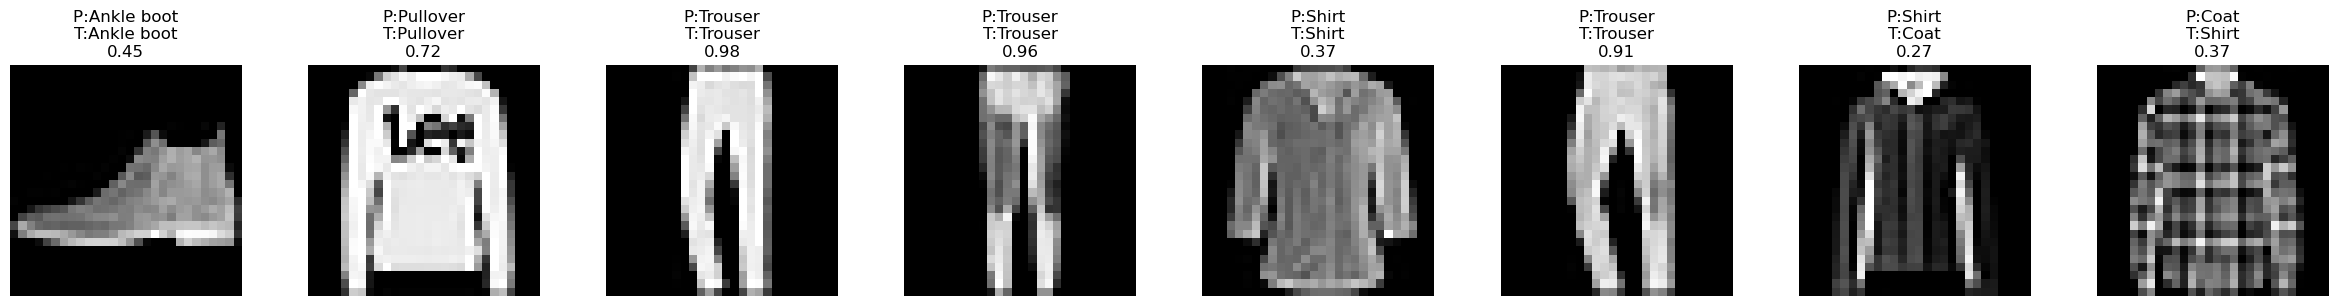

Test accuracy: 71.41% (7141/10000)


In [16]:
import matplotlib.pyplot as plt

# 类别名称（FashionMNIST）
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

model.eval()

# 显示一批样本的预测结果（取第一个 batch 的前 n 张）
n = 8
images, labels = next(iter(test_dataloader))
images_dev = images.to(device)
labels_dev = labels.to(device)

with torch.no_grad():
    logits = model(images_dev)
    probs = nn.Softmax(dim=1)(logits)
    preds = probs.argmax(dim=1)

# 可视化
fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
for i in range(n):
    img = images[i].squeeze(0).numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}\n{probs[i,preds[i]]:.2f}")
plt.tight_layout()
plt.show()

# 计算整个测试集准确率
correct = 0
total = 0
with torch.no_grad():
    for X, y in test_dataloader:
        X = X.to(device)
        y = y.to(device)
        out = model(X)
        pred = out.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

print(f"Test accuracy: {correct/total*100:.2f}% ({correct}/{total})")
# ...existing code...

#### 3. 保存模型和调取
在忙完一切之后，我们可以保存模型以备以后使用。

In [ ]:
# 保存模型的状态字典。'model.pth'是保存文件的名称，可以根据需要更改。
torch.save(model.state_dict(), 'model_weights.pth')
print("Model saved to model_weights.pth")

这样保存之后，我们可以通过
```python
# 重新创建模型结构
model = NeuralNetwork()  # 必须先定义相同的模型结构

# 确认计算模型的地方，不必和训练时在一个地方。既可以在GPU，也可以在CPU上。
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 加载状态字典
model.load_state_dict(torch.load('model_weights.pth', map_location=device))
model.eval()  # 设置为评估模式

print("Model loaded successfully!")
```
的方式重新加载模型。

### 附录：几个关键内容的下载方法

#### 1.  Fashion-MNIST 的数据集：
`root`为存储训练/测试数据的路径, 可以选择任何文件夹; `download`就代表下载. 由于我之前已经下载过了, 所以前序使用该函数的时候, 我都把`download`参数写入`False`避免重复下载.

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

#### 2. 另一个分类数据集 CIFAR10
它包含以下类别：“飞机”、“汽车”、“鸟”、“猫”、“鹿”、“狗”、“青蛙”、“马”、“船”、“卡车”。CIFAR-10 中的图像尺寸为 3x32x32，即 3 通道的彩色图像，尺寸为 32x32 像素。事后可以用这个训练集训着玩.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

#### 3. 关于安装Torch
1. 首先,在cmd/powershell 查看自己的GPU能支持到什么版本的CUDA. 输入`nvidia-smi`命令. 像我的会提示:
>  NVIDIA-SMI 537.34                 Driver Version: 537.34       CUDA Version: 12.2
就是最高支持到122。所以我个人用的是CUDA 121, 往下一个版本.
2. **不着急安装**CUDA. 先去[Torch官网](https://pytorch.org/)寻找`Install PyTorch`. 截至2025年末, 最新版本是torch 291 + CUDA 126/128/130. 如果这里的CUDA版本比自己支持的还高(比如我), 可以去[历史版本](https://pytorch.org/get-started/previous-versions/)里寻找适合自己的版本.
> 但是也不着急下载! 比如我找到的是Torch 251 + CUDA 121(因为人家没做122版本的,总之选低于自己最高支持版本的). 那么, 我去下载121版本的CUDA.
3. 知道自己下什么版本的CUDA之后, 安装. 安装完成后仍然通过cmd/powershell输入`nvcc --version`后确认是否安装完成. 这时候我的显示
> Built on Mon_Apr__3_17:36:15_Pacific_Daylight_Time_2023
>
> Cuda compilation tools, release 12.1, V12.1.105
>
> Build cuda_12.1.r12.1/compiler.32688072_0
就是成了.
4. 最后, 在Torch的网站把安装命令`pip3 install ...`复制进自己的环境-anaconda的prompt-输入, 回车, 等待安装.

#### 4. 关于环境
有时候, 不同的任务会逼迫我们选择不同的环境. 

比如我在学习另外一个教程[《动手学深度学习》](https://zh.d2l.ai/)的时候接触的Torch. 但是由于成书时间早, 那本书配套的数据集、命令库只适配到Py 3.9. 所以我特意为他创造了一个由3.9(而不是更新的Py3.13+)的环境.

习惯图形化界面的同学可以直接在Anaconda里创造新的环境. 不过Anaconda图形化界面有时候反应速度很慢. 所以急性子的同学, 建议直接用命令行解决:

打开Anaconda prompt. 输入
```bash
conda create --name 想要给环境起的名字 python = 想要安装的版本号
```
之后, 每次只要输入
```bash
conda activate 环境的名字
```
就算是切换到目标环境了.
这个时候, 再来执行我们所说的`conda install ...`或者`pip install...`等命令.